# 09b · Which drug–disease pairs rank poorly?

Per-pair ranking difficulty on the KG arm, and what drives it. All numbers are computed live
from the compiled runs; the figures are generated in the final section.


## Setup


In [22]:
import os, sys
from IPython.display import display
%matplotlib inline
BASE = os.getcwd()
while not os.path.exists(os.path.join(BASE, 'src', 'hard_pairs.py')) and os.path.dirname(BASE) != BASE:
    BASE = os.path.dirname(BASE)
sys.path.insert(0, BASE)
from src.headline_figures import load_runs
from src.hard_pairs import (compute_difficulty, cross_model_corr, fig_intrinsic_difficulty,
    fig_hardest_pairs, fig_difficulty_drivers, fig_difficulty_by_area, fig_coverage_fair, fig_age_effect)

GS = os.path.join(BASE, 'data', 'gold_standards')
df  = load_runs(os.path.join(BASE, 'results', 'tables', '09_llm_runs'))
per = compute_difficulty(df, os.path.join(GS, 'gold_standard_v4_bigset.tsv'),
                         os.path.join(GS, 'usable_pairs_v2_audited.csv'))
print(f'{len(per)} pairs · mean MRR on KG arm = {per.mrr.mean():.3f}')


ImportError: cannot import name 'fig_intrinsic_difficulty' from 'src.hard_pairs' (/Users/shil6661/biokgsuite/src/hard_pairs.py)

## Calculations

**Is difficulty intrinsic?** Correlate per-pair MRR across the three models — a high
correlation means hard pairs are hard for *every* model, not one model's quirk.


In [ ]:
r_models = cross_model_corr(per)
print(f'cross-model MRR correlation (avg pairwise) = {r_models:.2f}  ->  '
      f'{"intrinsic (hard for all models)" if r_models > 0.6 else "model-specific"}')


**Hard vs easy pairs** — split into MRR tertiles and compare the model's confidence, the share of consistent KG evidence, and KG coverage.


In [ ]:
q1, q2 = per.mrr.quantile([1/3, 2/3])
hard, easy = per[per.mrr <= q1], per[per.mrr >= q2]
import pandas as pd
cmp = pd.DataFrame({
    'hard third': [hard.conf.mean(), hard.frac_consistent.mean(), hard.n_kg.mean()],
    'easy third': [easy.conf.mean(), easy.frac_consistent.mean(), easy.n_kg.mean()]},
    index=['self-reported confidence (1-5)', 'share consistent KG evidence', '# KGs covering']).round(2)
cmp


**What predicts difficulty?** Pearson correlation of per-pair MRR with each covariate, and mean MRR by drug modality and approval year-set. (Confidence and consistent-evidence are downstream of the KG; coverage / recency / modality are intrinsic pair attributes.)


In [ ]:
from scipy import stats as st
rows = []
for c, lab in [('n_kg', 'KG coverage (# KGs)'), ('orig', 'drug approval year (recency)'),
               ('conf', 'self-reported confidence'), ('frac_consistent', 'consistent KG evidence')]:
    s = per[[c, 'mrr']].dropna(); r, p = st.pearsonr(s[c], s.mrr)
    rows.append({'covariate': lab, 'pearson_r': round(r, 2), 'p': round(p, 4), 'n': len(s)})
display(pd.DataFrame(rows))
print('\nmean MRR by drug modality:'); print(per.groupby('modality').mrr.mean().round(3).to_string())
print('\nmean MRR by approval year-set:'); print(per.groupby('year').mrr.mean().round(3).to_string())


**The hardest pairs** (lowest mean MRR).


In [ ]:
per[['disease', 'drug', 'area', 'mrr', 'hit1', 'n_kg']].head(15).reset_index(drop=True)


## Figures

Generated from `per` (re-run to refresh). Each shows once.

**1 · Difficulty is intrinsic** — pairwise per-disease MRR between the three models with the y=x line. Points hug the diagonal (high r), so the same pairs are hard for every model — not a per-model quirk.


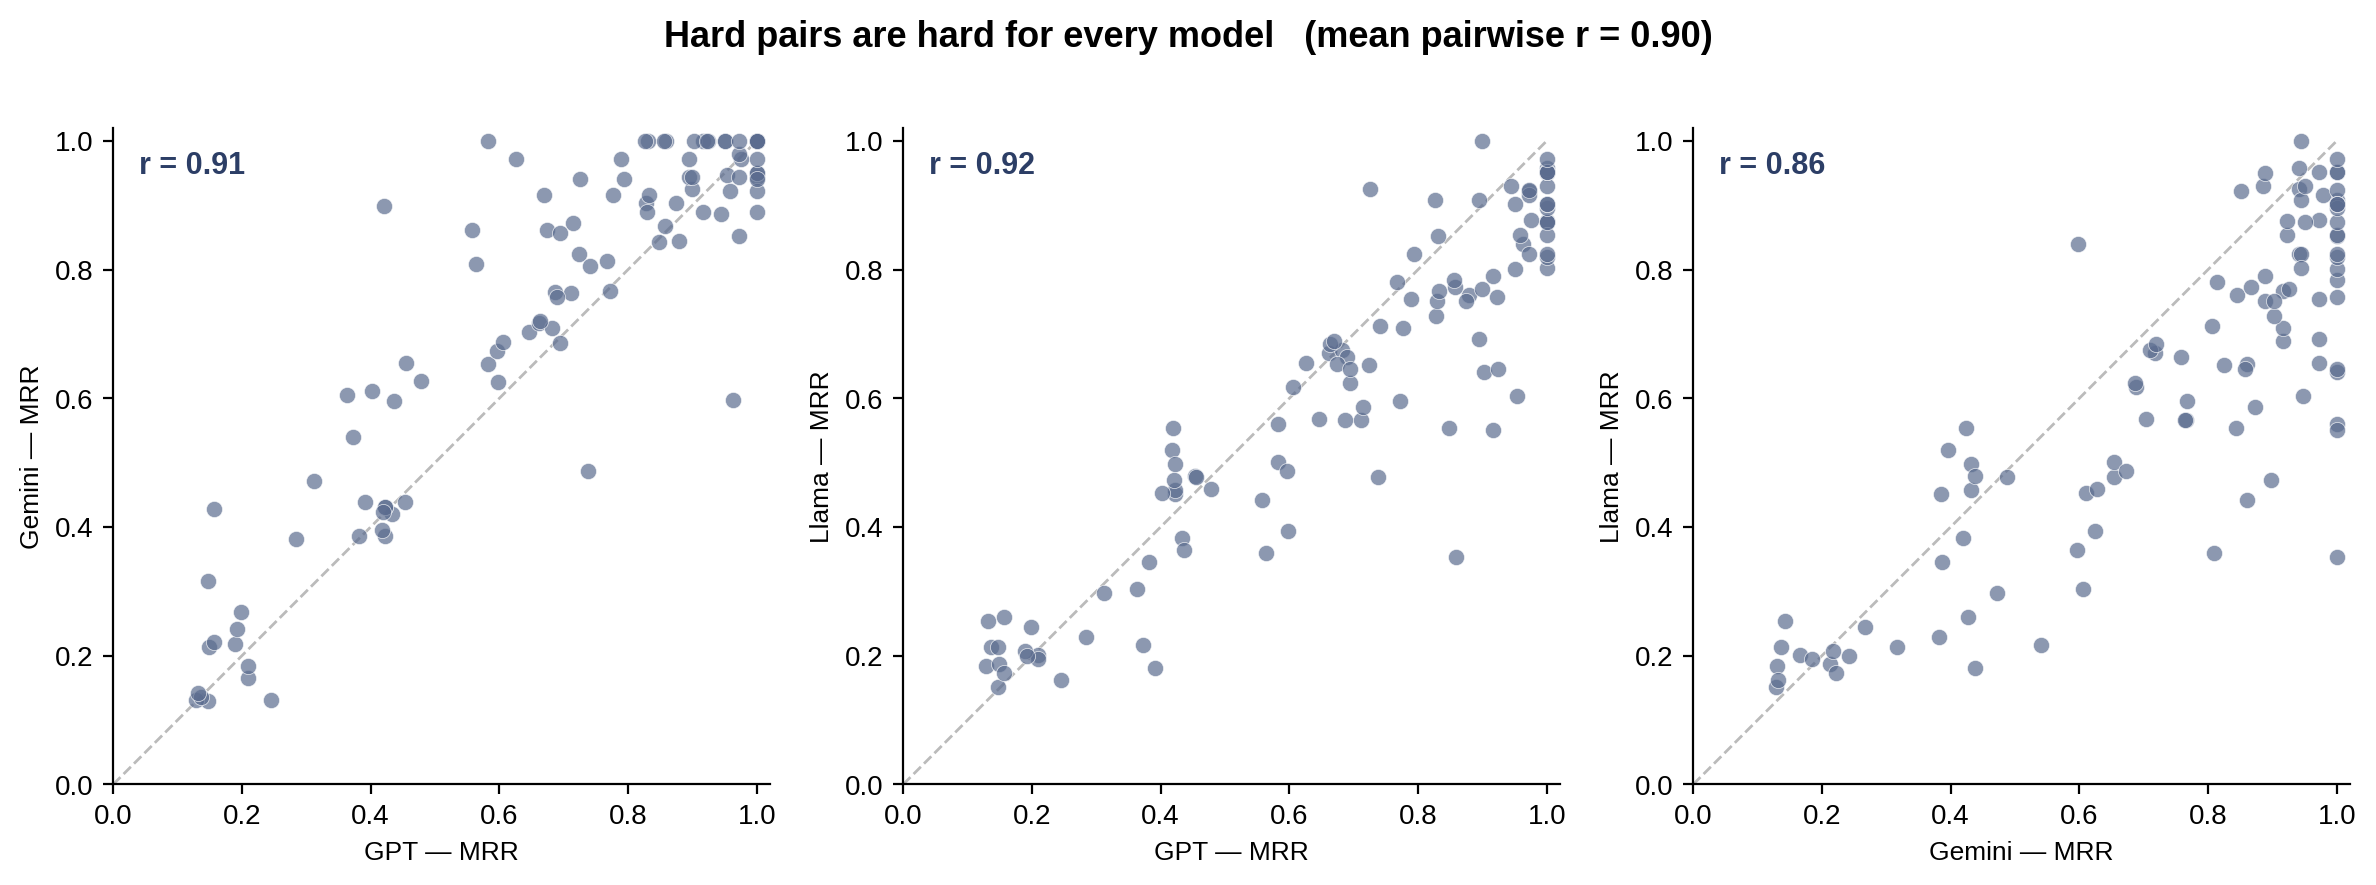

In [ ]:
fig_intrinsic_difficulty(per);


**2 · The hardest pairs** — pooled MRR (bar) with each model's MRR (dots); dots cluster, reinforcing that difficulty is shared across models.


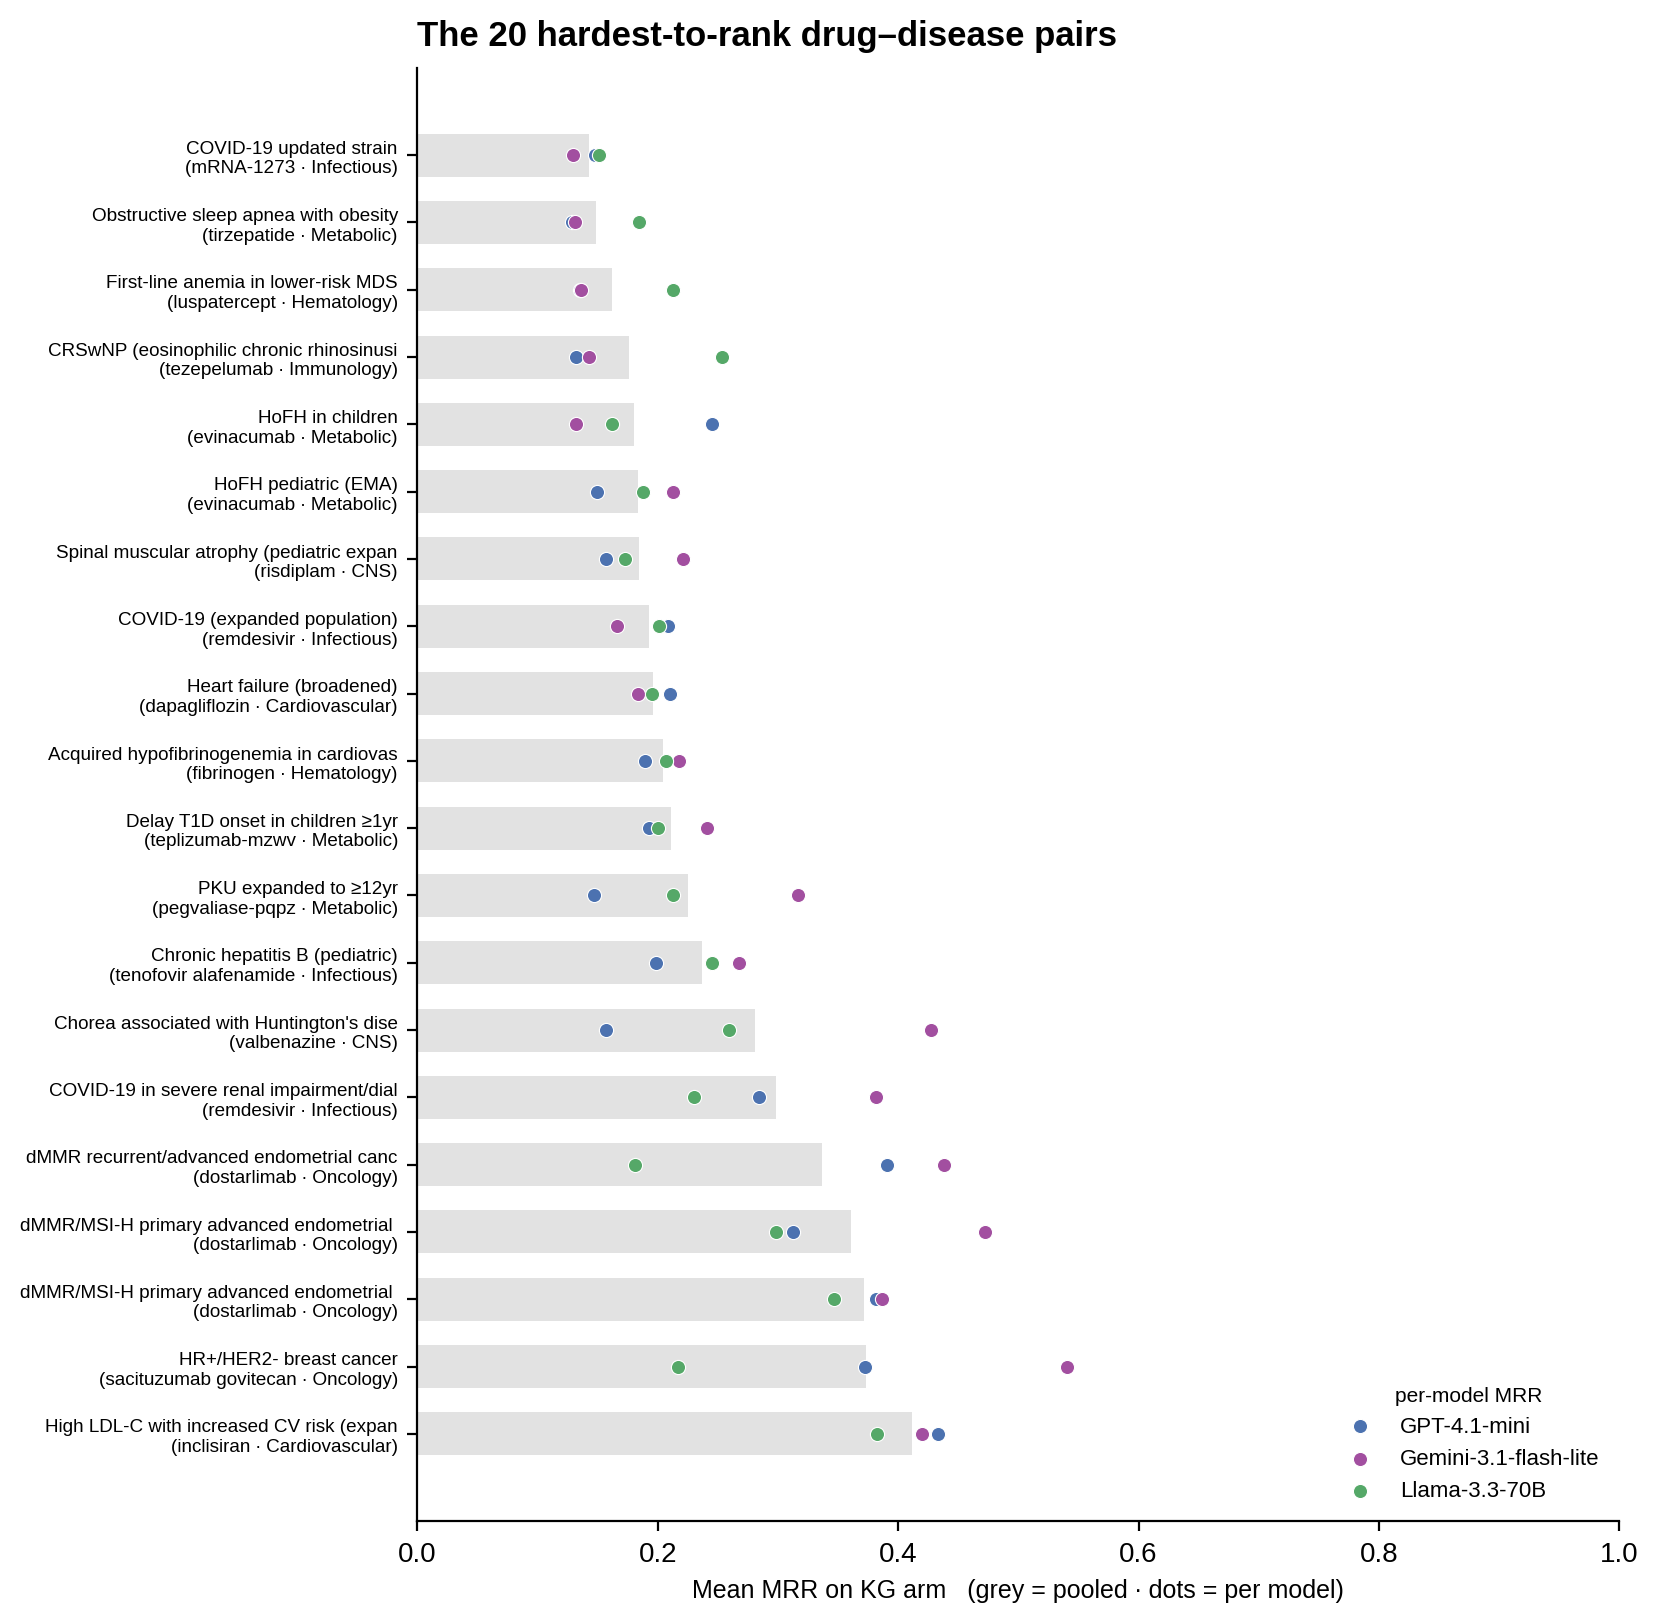

In [ ]:
fig_hardest_pairs(per);


**3 · Difficulty drivers** — per-pair MRR vs the model's confidence, coloured by the share of consistent KG evidence. The model is well-calibrated to its own difficulty.


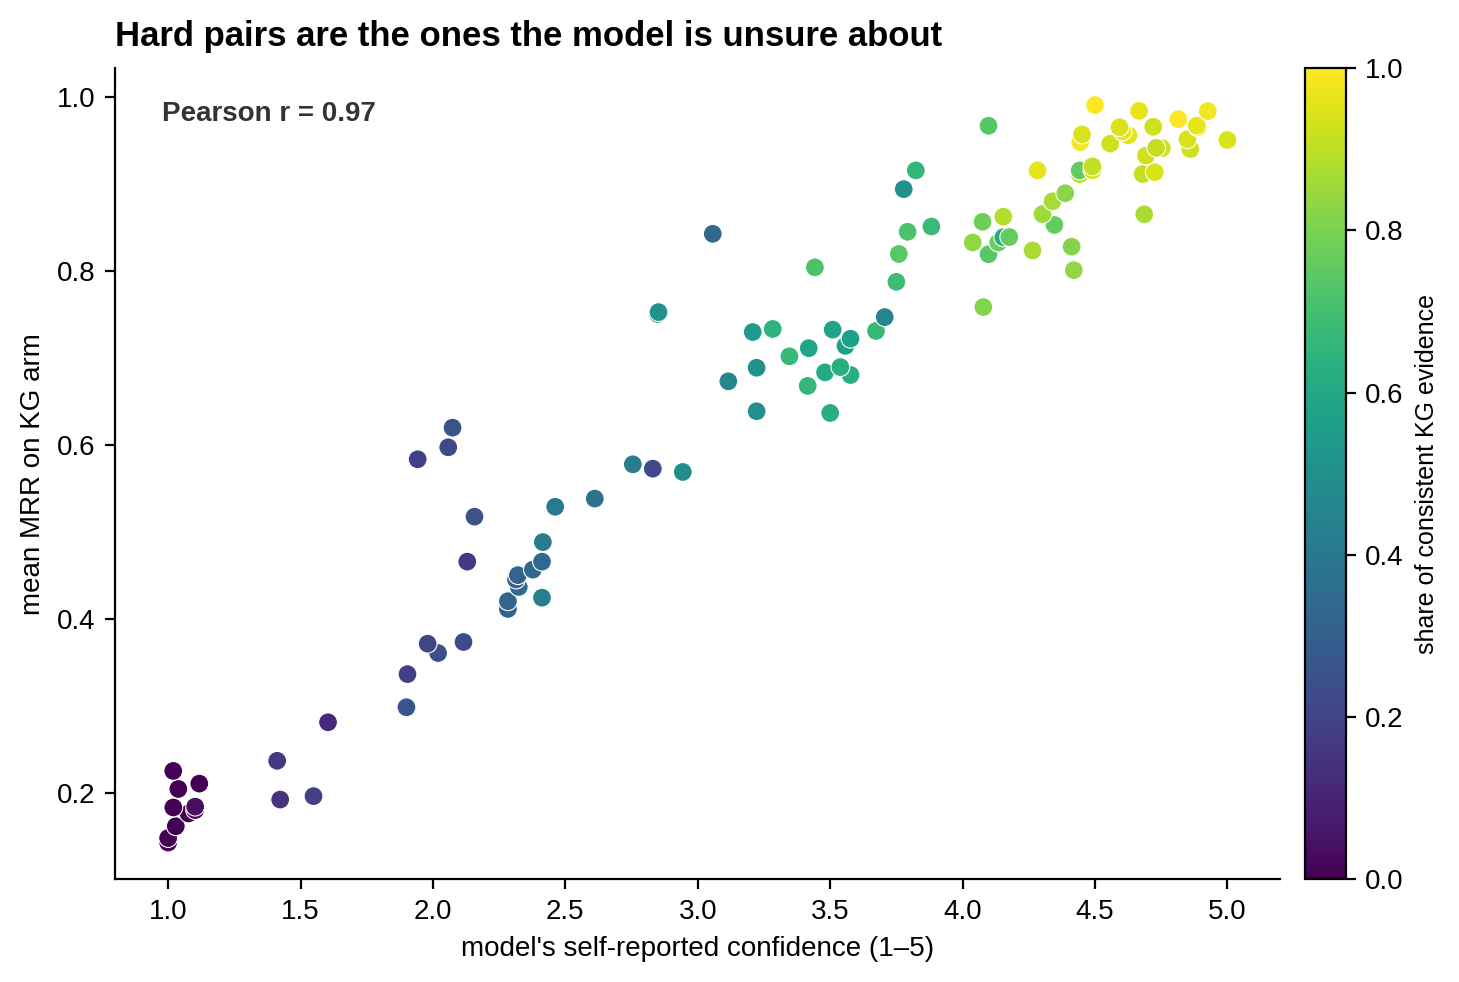

In [ ]:
fig_difficulty_drivers(per);


**4 · By therapeutic area** — dot per disease, diamond = area mean, sorted easiest→hardest.


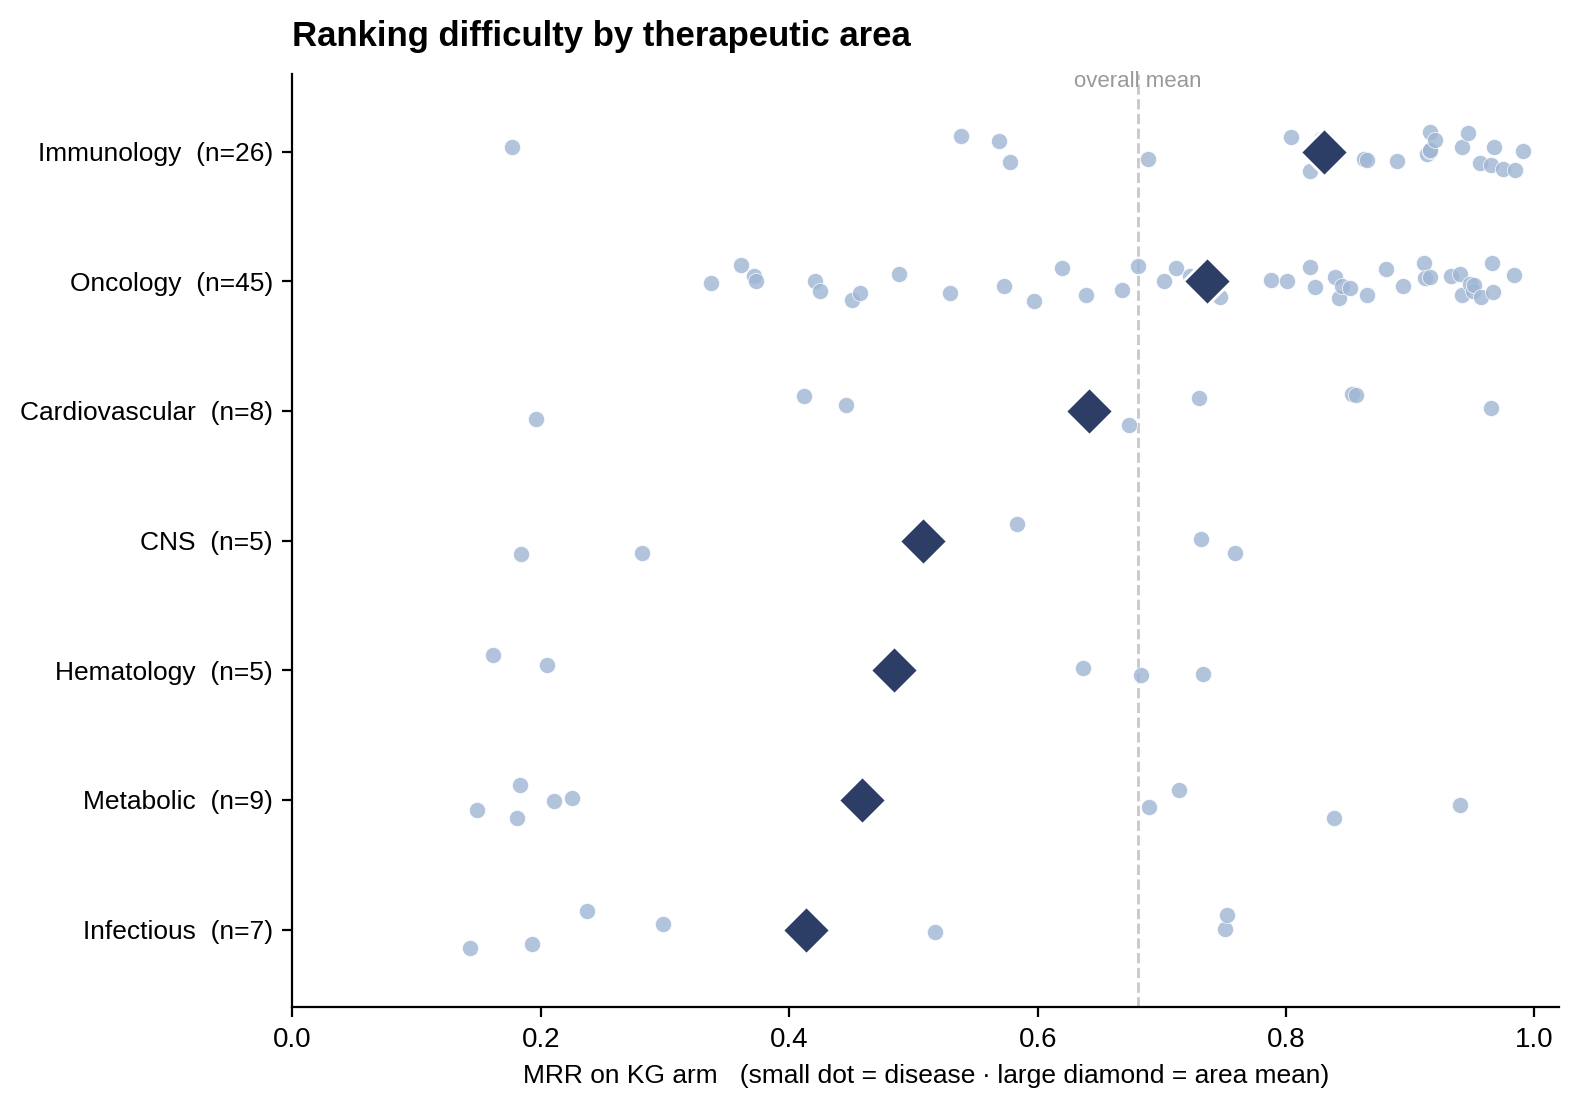

In [ ]:
fig_difficulty_by_area(per);


**5 · Coverage effect, fairly attributed** — number of KGs covering the pair is the axis that *does* predict pooled difficulty, but most of that is an **empty-arm averaging artifact**. The pooled line (grey, all three KG arms) dives at 1-KG pairs only because two of the three arms are empty and score near zero. Restricting to the **covered arm** (green) — the graph that actually contains the pair — the curve is nearly flat (~0.70-0.75): when a KG covers a pair, the model ranks it well regardless of how many *other* graphs also cover it. The small residual at 1-KG reflects genuinely thinner evidence, not a coverage penalty.


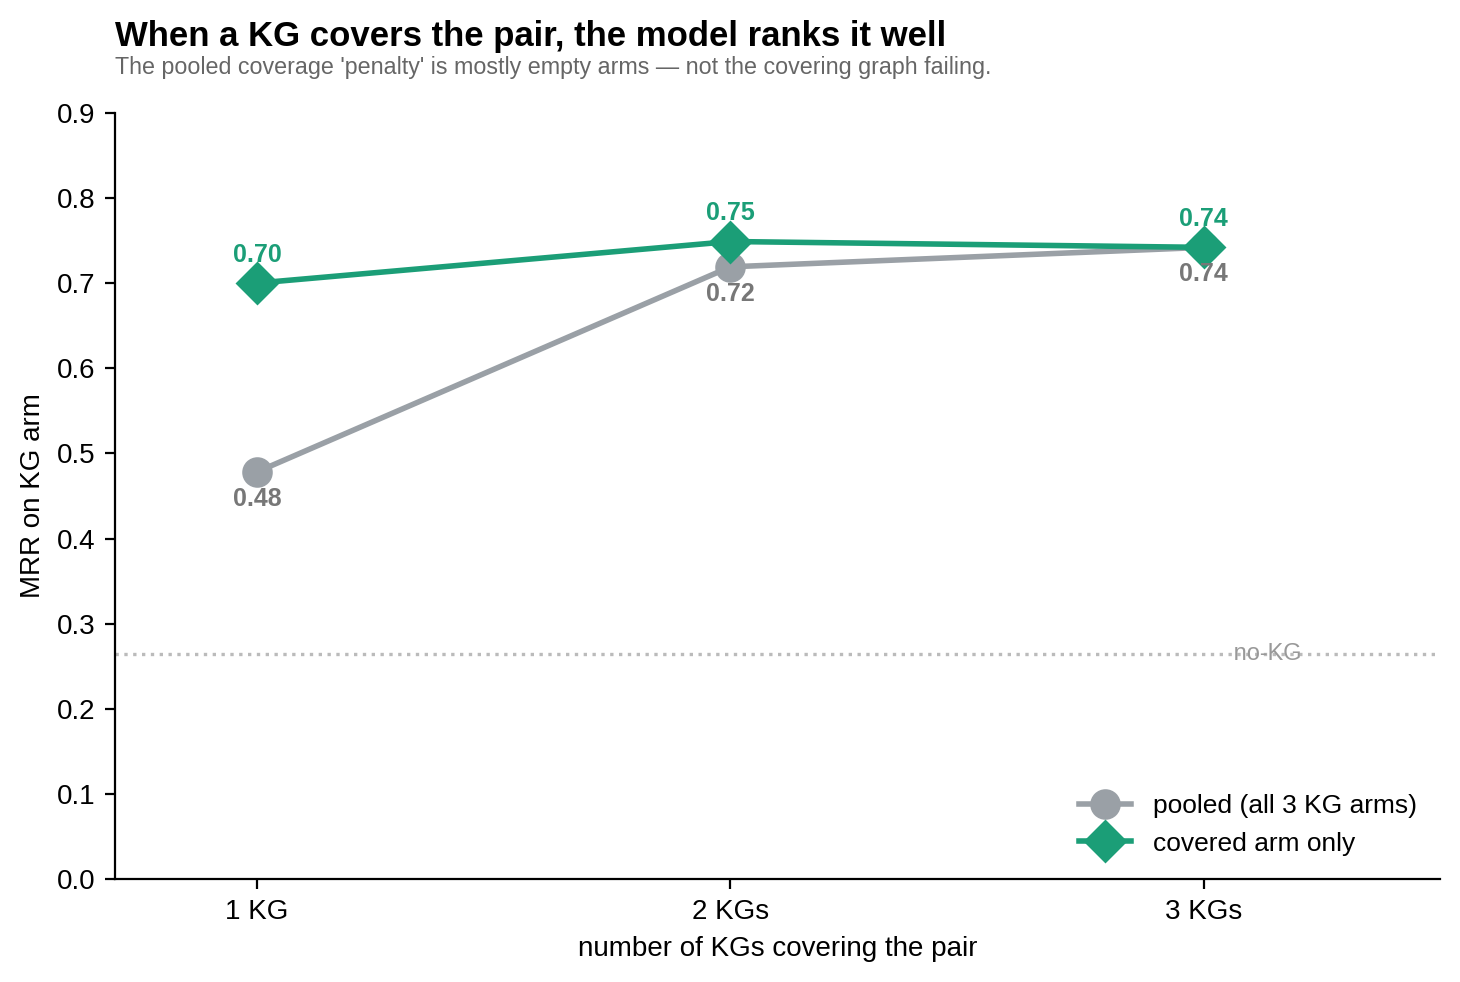

In [ ]:
fig_coverage_fair(df, os.path.join(GS, 'coverage_annotation_v4.csv'));


**6 · Drug age (null)** — original approval year vs MRR; recency does **not** predict difficulty.


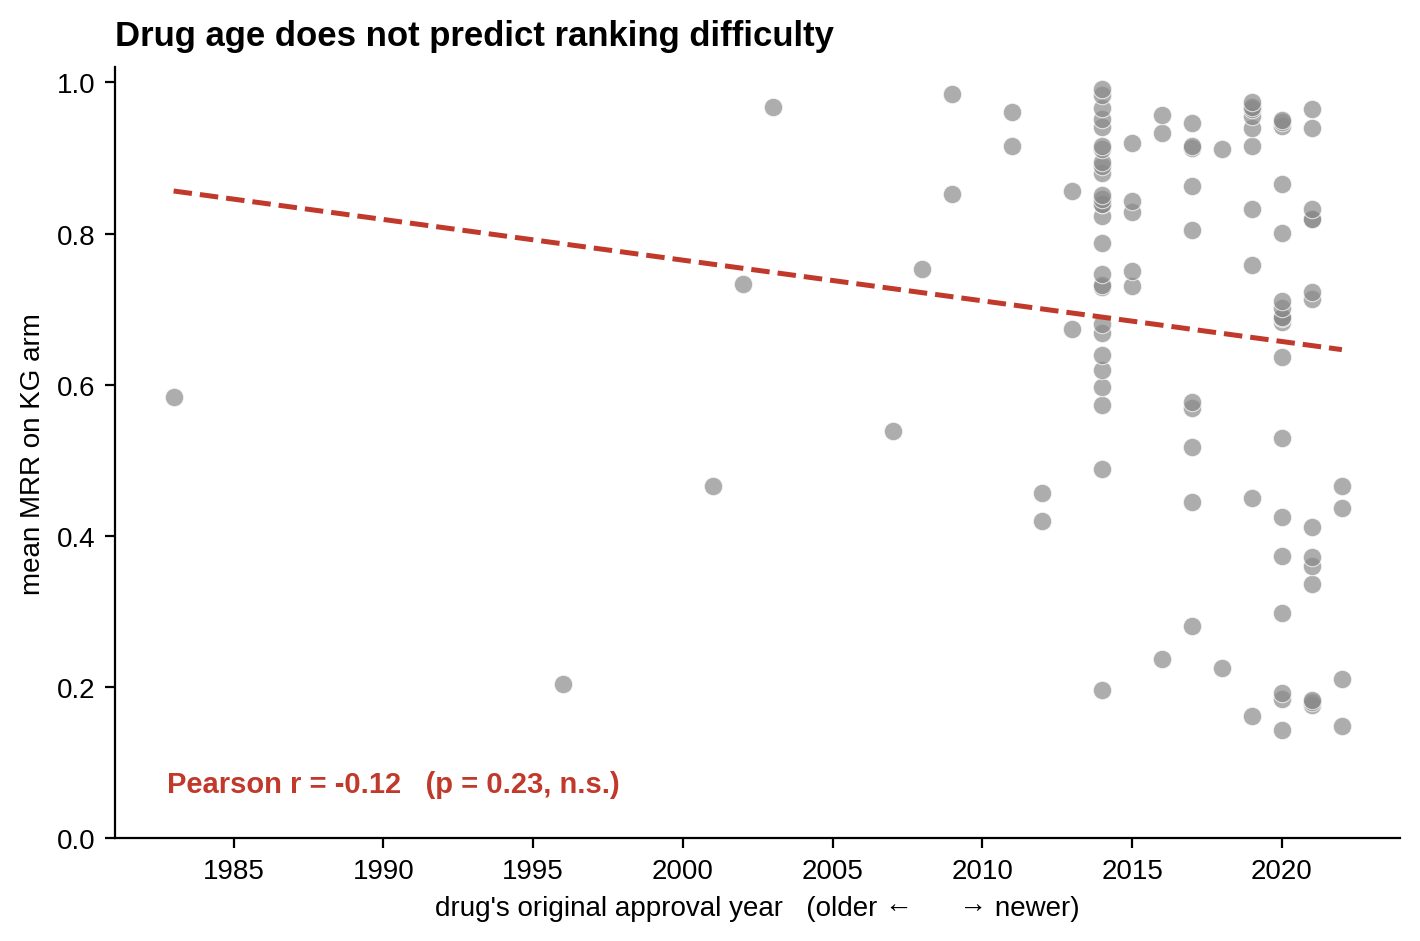

In [ ]:
fig_age_effect(per);


## Takeaways

- Difficulty is **intrinsic** — hard pairs are hard for all three models (see the cross-model
  correlation above).
- The model is **calibrated to difficulty**: hard pairs are exactly the low-confidence,
  low-consistent-evidence ones.
- The intrinsic attribute that predicts *pooled* difficulty is **KG coverage** — but most of that is
  an empty-arm averaging artifact: on the covered arm the curve is nearly flat (Figure 5). Drug age,
  modality and approval year-set are all near-null (table above).

*Engine: `src/hard_pairs.py`. Per-pair table written to `results/tables/hard_pairs.csv` if you call `per.to_csv(...)`.*
